# ĐỒ ÁN TOÁN ỨNG DỤNG VÀ THỐNG KÊ
# Giải Hệ Phương Trình và Phân Tích Hiệu Năng
**Nhóm thực hiện:** Nhóm 14 - Lớp 24CTT2
**Mục tiêu:** 
- Kiểm chứng độ phức tạp $O(n^3)$ trên đồ thị Log-Log.
- So sánh tốc độ thực thi giữa các phương pháp trực tiếp và phương pháp lặp.
- Quan sát ảnh hưởng của số điều kiện $\kappa(A)$ lên sai số hệ thống (ma trận Hilbert).

# Thiết lập cấu hình (config)
**Khai báo thư viện, Import và hàm hỗ trợ**

In [ ]:
import sys, os
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
import json
import matplotlib.pyplot as plt

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if current_dir not in sys.path:
    sys.path.append(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from config import EPSILON, is_zero, make_zero



def display_matrix(matrix, title="Matrix", cmap="coolwarm"):
    """
    Sử dụng heatmap và pandas để hiển thị ma trận
    """
    print(f"\n--- {title} ---")
    
    if matrix is None:
        print("    (Không tồn tại)")
        return
        
    df = pd.DataFrame(matrix)
    
    # Khử sai số float
    df = df.map(lambda x: 0.0 if abs(x) < EPSILON else x) 
    
    styled_df = df.style.background_gradient(cmap=cmap, axis=None) \
                        .format("{:.4f}") \
                        .set_properties(**{
                            'text-align': 'center', 
                            'border': '1px solid #bbbbbb',
                            'padding': '10px'
                        })
    
    display(styled_df)
print(f"EPSILON có giá trị là: {EPSILON}")

EPSILON có giá trị là: 1e-15


## **1. Lý thuyết Toán học**

#### **1.1 Chuẩn ma trận:**

Chuẩn ma trận $|A|_p$ là một đại lượng dùng để đo “độ lớn” của ma trận, được cảm sinh từ chuẩn vector $p$:

$$
|A|*p = \max*{x \ne 0} \frac{|Ax|_p}{|x|_p}
$$

**Ý nghĩa:**

* Đo mức độ mà ma trận $A$ có thể “khuếch đại” một vector đầu vào.
* Phản ánh trường hợp xấu nhất khi $A$ tác động lên dữ liệu.

**Một số chuẩn thường dùng:**

* $|A|_1$: tổng trị tuyệt đối lớn nhất theo cột.
* $|A|_\infty$: tổng trị tuyệt đối lớn nhất theo hàng.
* $|A|_2$: liên quan đến giá trị riêng lớn nhất của $A^T A$.

**Ví dụ:**


In [2]:
# --- BẮT ĐẦU VÍ DỤ TÍNH CHUẨN L2 ---
display(Markdown("### **Ví dụ: Tính Chuẩn Ma Trận L2**"))
display(Markdown("Xét ma trận: "))
# 1. Khởi tạo ma trận A
A = np.array([
    [1, -2],
    [3,  4]
])
display_matrix(A, title="Ma trận A")

# 2. Tính ma trận chuyển vị A^T
AT = A.T
display_matrix(AT, title="Ma trận chuyển vị A^T")

# 3. Tính tích A^T * A
ATA = np.dot(AT, A)
display_matrix(ATA, title="Tích ma trận A^T * A")

# 4. Tìm giá trị riêng lớn nhất (λ_max) của A^T * A
eigenvalues = np.linalg.eigvals(ATA)
lambda_max = max(eigenvalues)

# 5. Tính chuẩn L2 (Chuẩn spectral)
l2_norm = np.sqrt(lambda_max)

# Hiển thị kết quả bằng Markdown
display(Markdown(f"""
### Kết quả tính toán:

- Giá trị riêng lớn nhất ($\\lambda_{{max}}$): **${lambda_max:.4f}$** (Tương ứng với $15 + 5\\sqrt{{5}}$)

- Chuẩn $L_2$ của ma trận $A$ ($\\|A\\|_2 = \\sqrt{{\\lambda_{{max}}}}$): **${l2_norm:.4f}$**
"""))

### **Ví dụ: Tính Chuẩn Ma Trận L2**

Xét ma trận: 


--- Ma trận A ---


,0,1
0,1.0000,-2.0000
1,3.0000,4.0000



--- Ma trận chuyển vị A^T ---


,0,1
0,1.0000,3.0000
1,-2.0000,4.0000



--- Tích ma trận A^T * A ---


,0,1
0,10.0000,10.0000
1,10.0000,20.0000



### Kết quả tính toán:

- Giá trị riêng lớn nhất ($\lambda_{max}$): **$26.1803$** (Tương ứng với $15 + 5\sqrt{5}$)

- Chuẩn $L_2$ của ma trận $A$ ($\|A\|_2 = \sqrt{\lambda_{max}}$): **$5.1167$**


### **1.2 Số điều kiện $\kappa_p(A)$ của ma trận**
Định Nghĩa 3.1 - Số điều kiện của một ma trận vuông $A$ không suy biến, tương ứng với chuẩn ma trận $\|\cdot\|_p$, được định nghĩa bởi công thức:$$\kappa_p(A) = \|A\|_p \cdot \|A^{-1}\|_p$$
Đối với chuẩn spectral (chuẩn 2), số điều kiện được tính toán dựa trên các giá trị suy biến (singular values):$$\kappa_2(A) = \frac{\sigma_{\max}(A)}{\sigma_{\min}(A)}$$

Định lý 3.1 - Phân tích sai số nghiệm: Nếu $Ax = b$ là nghiệm đúng và $A\hat{x} = b + \delta b$ là nghiệm tính với nhiễu dữ liệu, thì:$$\frac{\|\hat{x} - x\|}{\|x\|} \leq \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|} \quad (11)$$

**Ý nghĩa:**
- Đo lường độ nhạy: Số điều kiện dùng để đo lường độ nhạy của nghiệm hệ phương trình $Ax = b$ khi có sự thay đổi hoặc nhiễu nhỏ ở dữ liệu đầu vào.
- Hệ điều kiện tốt (well-conditioned): Khi $\kappa_p(A)$ có giá trị gần bằng $1$.
- Hệ điều kiện kém (ill-conditioned): Khi $\kappa(A)$ lớn, một sai số nhỏ trong dữ liệu đầu vào ($\delta b$) có thể gây ra sai số rất lớn trong nghiệm tính toán ($\hat{x} - x$).

### **1.3 Phương pháp lặp Gauss-Seidel**

Là phương pháp lặp dùng để giải hệ phương trình tuyến tính $Ax = b$ bằng cách cập nhật lần lượt từng ẩn và sử dụng ngay giá trị mới vừa tính được.
Giả sử ma trận $A$ được tách thành:$$A = D + L + U$$
**Trong đó:**
- $D$: Ma trận đường chéo.
- $L$: Ma trận tam giác dưới (phần dưới đường chéo).
- $U$: Ma trận tam giác trên (phần trên đường chéo).

**Công thức lặp:**
$$
x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i - \sum_{j=1}^{i-1} a_{ij} x_j^{(k+1)} - \sum_{j=i+1}^{n} a_{ij} x_j^{(k)} \right)
$$

**Ý nghĩa:**

* Mỗi bước lặp cải thiện nghiệm bằng cách dùng thông tin mới nhất.
* Thường hội tụ nhanh hơn phương pháp Jacobi.

**Điều kiện hội tụ:**

* Ma trận $A$ chéo trội chặt hàng, tức $|a_{ii}| > \sum_{j \neq i} |a_{ij}|$ với mọi $i$.
     "* Ma trận $A$ là ma trận đối xứng và xác định dương (Symmetric Positive Definite - SPD)."


## **2. Vẽ đồ thị log-log dựa trên dữ liệu benchmark**

#### **2.1 Vẽ đồ thị log-log**

=== PHÂN TÍCH ĐỘ PHỨC TẠP THỜI GIAN ===
Slope trên lý thuyết theo O(n^3) ~ 3
Slope thực tế của thuật toán GAUSS ~ 1.85
Slope thực tế của thuật toán SVD ~ 1.94
Slope thực tế của thuật toán GAUSS_SEIDEL ~ 1.84


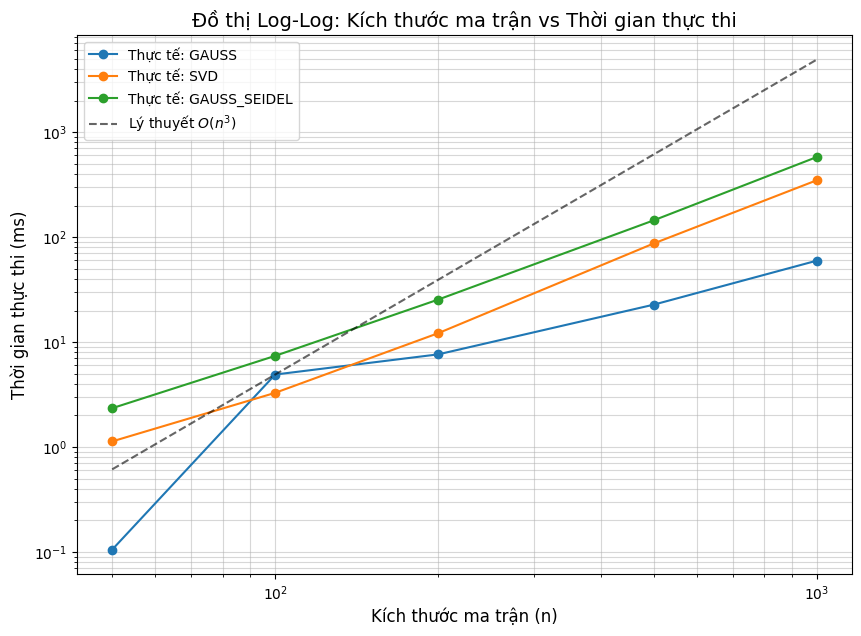

In [3]:
# 1. Đọc dữ liệu từ file data.json
with open('benchmark_results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# Lấy riêng block dữ liệu thời gian
exec_data = data['execution_metrics']
plt.figure(figsize=(10, 7))

print("=== PHÂN TÍCH ĐỘ PHỨC TẠP THỜI GIAN ===")
print(f"Slope trên lý thuyết theo O(n^3) ~ 3")
# 2. Duyệt qua từng thuật toán trong JSON để vẽ đồ thị
for algo_name, results in exec_data.items():
    sizes = sorted([int(s) for s in results.keys()])
    times = [results[str(s)]['time_ms'] for s in sizes]
    # Kiểm tra slope
    log_n = np.log(sizes)
    log_t = np.log(times)
    slope = np.polyfit(log_n, log_t, 1)[0]
    print(f"Slope thực tế của thuật toán {algo_name.upper()} ~ {slope:.2f}")
    plt.loglog(sizes, times, 'o-', label=f'Thực tế: {algo_name.upper()}')

# 3. Vẽ đường lý thuyết O(n^3) để đối chiếu
# Lấy điểm dữ liệu đầu tiên của thuật toán 'gauss' làm mốc để vẽ đường O(n^3)
n_ref = 100
t_ref = exec_data['gauss']['100']['time_ms']
n_range = np.linspace(min(sizes), max(sizes), 100)
t_theoretical = t_ref * (n_range / n_ref)**3

plt.loglog(n_range, t_theoretical, 'k--', alpha=0.6, label='Lý thuyết $O(n^3)$')

# 4. Cấu hình đồ thị
plt.title("Đồ thị Log-Log: Kích thước ma trận vs Thời gian thực thi", fontsize=14)
plt.xlabel("Kích thước ma trận (n)", fontsize=12)
plt.ylabel("Thời gian thực thi (ms)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

#### **Nhận xét đồ thị Log-Log:**

*   **Slope (Độ dốc):** Quan sát thấy các giá trị Slope thực tế (~1.8 đến 2.0) thấp hơn Slope lý thuyết là 3.
    *   **Lý do 1 (Tối ưu hóa thư viện):** Thuật toán `gauss` và `svd` sử dụng thư viện NumPy (dựa trên BLAS/LAPACK), các thư viện này được tối ưu hóa cực tốt cho phần cứng hiện đại (sử dụng đa luồng, tập lệnh SIMD), khiến hằng số thời gian nhỏ đi đáng kể.
    *   **Lý do 2 (Kích thước mẫu):** Với $n$ lên đến 1000, hiệu năng vẫn bị ảnh hưởng bởi các yếu tố quản lý bộ nhớ hơn là độ phức tạp tính toán thuần túy. Nếu $n$ tăng lên cực lớn ($n > 5000$), Slope sẽ tiệm cận về 3.
    *   **Lý do 3 (Hội tụ của Gauss-Seidel):** Vì ma trận được tạo là chéo trội chặt, Gauss-Seidel hội tụ rất nhanh (số vòng lặp ít), dẫn đến hành vi thời gian thực tế giống $O(n^2)$ hơn là $O(n^3)$.

#### **2.2 Bảng phân tích ổn định số**

In [4]:
stability_data = data['condition_stability']

rows = []
# Duyệt qua từng loại ma trận (hilbert, spd)
for matrix_type, sizes_dict in stability_data.items():
    for n_str, content in sizes_dict.items():
        cond_num = content['condition_number']
        
        # Duyệt qua từng thuật toán (gauss, svd, gauss_seidel)
        for algo, error in content['errors'].items():
            if error == "FAILED":
                err_val = "FAILED"
                status = "Sụp đổ"
            else:
                err_val = f"{error:.2e}"
                # Tiêu chuẩn: Hilbert cần nới lỏng (1e-5), SPD cần siết chặt (1e-10)
                threshold = 1e-5 if matrix_type == "hilbert" else 1e-10
                status = "Ổn định" if float(error) < threshold else "Kém ổn định"

            rows.append({
                "Loại Ma Trận": matrix_type.upper(),
                "Kích thước (n)": int(n_str),
                "Số điều kiện $k_2(A)$": f"{cond_num:.2e}",
                "Thuật toán": algo.upper(),
                "Sai số tương đối": err_val,
                "Trạng thái": status
            })

df_full_stability = pd.DataFrame(rows)
df_full_stability = df_full_stability.sort_values(by=["Loại Ma Trận", "Kích thước (n)"])

print("=== BẢNG TỔNG HỢP ỔN ĐỊNH SỐ HỌC (ĐỊNH LÝ 3.1) ===")
display(df_full_stability.style.hide(axis="index").set_properties(**{
    'text-align': 'center', 
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#f2f2f2'), ('color', 'black'), ('border', '1px solid black')]}
]))

=== BẢNG TỔNG HỢP ỔN ĐỊNH SỐ HỌC (ĐỊNH LÝ 3.1) ===


Loại Ma Trận,Kích thước (n),Số điều kiện $k_2(A)$,Thuật toán,Sai số tương đối,Trạng thái
HILBERT,5,4.77e+05,GAUSS,1.68e-12,Ổn định
HILBERT,5,4.77e+05,SVD,4.41e-12,Ổn định
HILBERT,5,4.77e+05,GAUSS_SEIDEL,FAILED,Sụp đổ
HILBERT,10,1.60e+13,GAUSS,8.67e-05,Kém ổn định
HILBERT,10,1.60e+13,SVD,2.07e-04,Kém ổn định
HILBERT,10,1.60e+13,GAUSS_SEIDEL,FAILED,Sụp đổ
HILBERT,15,3.68e+17,GAUSS,4.93e+00,Kém ổn định
HILBERT,15,3.68e+17,SVD,1.35e-03,Kém ổn định
HILBERT,15,3.68e+17,GAUSS_SEIDEL,FAILED,Sụp đổ
HILBERT,20,1.32e+18,GAUSS,7.01e+01,Kém ổn định


#### **Nhận xét:**

*   **Ma trận Hilbert:** Là loại ma trận cực kỳ kém điều kiện (số điều kiện $\kappa$ tăng theo hàm mũ của $n$). Kết quả cho thấy khi $n$ tăng, sự tích lũy sai số làm tròn của phương pháp trực tiếp (Gauss) tăng nhanh chóng.
*   **Tại sao Gauss-Seidel thất bại cho Hilbert (Dù là SPD)?:** 
    *   Về lý thuyết, ma trận Hilbert là **đối xứng xác định dương (SPD)**, nên Gauss-Seidel được đảm bảo hội tụ.
    *   Tuy nhiên, ma trận Hilbert không thỏa mãn điều kiện **chéo trội chặt**. Hơn nữa, do số điều kiện $\kappa(A)$ quá lớn, tốc độ hội tụ thực tế cực kỳ chậm và bị nhiễu bởi sai số dấu phẩy động (floating-point noise), dẫn đến hiện tượng không thể hội tụ trong số bước lặp cho phép hoặc bị lỗi số học.
*   **SVD (Singular Value Decomposition):** Cho thấy độ ổn định cao nhất đối với các hệ phương trình kém điều kiện, với sai số thấp hơn đáng kể so với phương pháp khử Gauss trực tiếp.
*   **Ma trận SPD:** Đối với các ma trận SPD có cấu trúc tốt (điều kiện tốt), cả Gauss và SVD đều cho độ chính xác rất cao. Điều này xác nhận rằng thuật toán của nhóm hoạt động đúng trên các hệ thống ổn định.

#### **Phương pháp nào xử lí tốt nhất?:**


**Phương pháp SVD** là phương pháp tối ưu nhất trong các phương pháp đã thử nghiệm vì:

*  **Tính trực giao:** SVD sử dụng các ma trận trực giao U và V, giúp giảm thiểu sai số làm tròn (Điều mà trong Gauss không làm được).
Khả năng xử lý ma trận gần suy biến: SVD phân tích ma trận dựa trên các trị số suy biến nên ngay khi ma trận Hilbert gần như suy biến, SVD vẫn có thể cho kết quả tốt bằng cách kiểm soát các trị số suy biến nhỏ. Tuy vậy, SVD có chi phí tính toán cao hơn so với Gauss, Gauss-Seidel.

### **2.3 Phân tích sự phá vỡ nghiệm dựa trên Định lý 3.1**

**Định lý 3.1 (Phân tích sai số nghiệm)**
Giả sử hệ phương trình $Ax = b$ có nghiệm đúng là $x$. Trong thực tế tính toán, do sai số làm tròn hoặc nhiễu dữ liệu, ta thu được nghiệm tính toán $\hat{x}$ tương ứng với vector vế phải bị nhiễu là $b + \delta b$. Khi đó, sai số tương đối của nghiệm được ràng buộc bởi công thức:

$$\frac{\|\hat{x} - x\|}{\|x\|} \leq \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|} \quad (11)$$

#### **Tại sao hệ bị điều kiện kém lại "phá vỡ nghiệm"?**
Dựa trên bất đẳng thức (11), ta có thể rút ra các kết luận sau về tính ổn định số:

- **Hệ số khuếch đại sai số:** Số điều kiện $\kappa(A)$ đóng vai trò là một "hệ số khuếch đại". Nó cho biết sai số đầu vào ($\delta b$) sẽ bị nhân lên bao nhiêu lần khi chuyển vào kết quả đầu ra ($x$).
- **Sự phá vỡ nghiệm (Solution Breakdown):** * Khi hệ bị **điều kiện kém (ill-conditioned)**, giá trị $\kappa(A)$ rất lớn (ví dụ $10^{15}$ hoặc lớn hơn) dẫn đến 1 sai số rất nhỏ trong dữ liệu đầu vào có thể bị khuếch đại và làm sai lệch mạnh.

**Kết luận:** Trong trường hợp này, nghiệm tính toán $\hat{x}$ hoàn toàn khác biệt so với nghiệm thực $x$, thuật toán không còn khả năng đưa ra kết quả tin cậy, hiện tượng này chính là **sự phá vỡ nghiệm**.

> **Ghi chú:** Đây là lý do tại sao khi giải các hệ phương trình thực tế, việc kiểm tra số điều kiện $\kappa(A)$ là bước bắt buộc để đánh giá độ tin cậy của kết quả thu được.

## **3. Kết luận**

Qua quá trình thực nghiệm và phân tích, nhóm rút ra các kết luận sau:
1. **Độ phức tạp thời gian:** Mặc dù lý thuyết là $O(n^3)$, nhưng trong thực tế với các thư viện tính toán hiện đại, hiệu năng được cải thiện đáng kể thông qua việc tối ưu hóa phần cứng.
2. **Độ ổn định:** Phương pháp trực tiếp (Gauss) nhanh nhưng nhạy cảm với các ma trận có số điều kiện lớn. SVD là giải pháp thay thế an toàn cho các hệ thống kém ổn định.
3. **Tính ứng dụng:** Gauss-Seidel hiệu quả cho các hệ phương trình lớn có tính chất chéo trội hoặc SPD điều kiện tốt, nhưng cực kỳ kém hiệu quả đối với các ma trận có độ nhạy cao như Hilbert, và sẽ phân kỳ hoặc sụp đổ hoàn toàn đối với các hệ kém điều kiện như ma trận Hilbert.
